# 03 — Exploratory Data Analysis

## But First, Coffee: Competitive Revenue Intelligence

### Purpose

This notebook explores the cleaned competitive dataset to identify pricing patterns, customer-experience patterns, market-positioning differences, and potential revenue opportunities for But First, Coffee.

The analysis focuses on:

1. Dataset validation
2. Menu and pricing distributions
3. Matched competitive product pricing
4. Promotional pricing patterns
5. Customer-experience theme prevalence
6. Management-level customer-experience dimensions
7. Branch/platform aggregate-rating context
8. Individual-rating descriptive analysis
9. Outlier detection
10. Relationships relevant to revenue management

Formal hypothesis testing is reserved for Notebook 04.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("EDA libraries loaded successfully.")

EDA libraries loaded successfully.


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_CLEANED = PROJECT_ROOT / "data" / "cleaned"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES = PROJECT_ROOT / "outputs" / "tables"

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned data:", DATA_CLEANED)
print("Figures:", FIGURES)
print("Tables:", TABLES)

Project root: /Users/jannoelvero/Desktop/but_first_coffee_revenue_analysis
Cleaned data: /Users/jannoelvero/Desktop/but_first_coffee_revenue_analysis/data/cleaned
Figures: /Users/jannoelvero/Desktop/but_first_coffee_revenue_analysis/outputs/figures
Tables: /Users/jannoelvero/Desktop/but_first_coffee_revenue_analysis/outputs/tables


In [3]:
reviews = pd.read_csv(
    DATA_CLEANED / "reviews_cleaned.csv"
)

menu_prices = pd.read_csv(
    DATA_CLEANED / "menu_prices_cleaned.csv"
)

store_footprint = pd.read_csv(
    DATA_CLEANED / "store_footprint_cleaned.csv"
)

channels = pd.read_csv(
    DATA_CLEANED / "channels_partnerships_cleaned.csv"
)

menu_breadth = pd.read_csv(
    DATA_CLEANED / "menu_breadth_cleaned.csv"
)

official_menu = pd.read_csv(
    DATA_CLEANED / "official_menu_cleaned.csv"
)

official_capabilities = pd.read_csv(
    DATA_CLEANED / "official_capabilities_cleaned.csv"
)

individual_ratings = pd.read_csv(
    DATA_CLEANED / "individual_ratings_cleaned.csv"
)

matched_family_prices = pd.read_csv(
    DATA_CLEANED / "matched_family_prices.csv"
)

branch_rating_records = pd.read_csv(
    DATA_CLEANED / "branch_rating_records.csv"
)

theme_brand_prevalence = pd.read_csv(
    DATA_CLEANED / "theme_brand_prevalence.csv"
)

dimension_prevalence = pd.read_csv(
    DATA_CLEANED / "dimension_prevalence.csv"
)

print("Cleaned datasets loaded successfully.")

Cleaned datasets loaded successfully.


In [4]:
eda_dataset_sizes = pd.DataFrame({
    "dataset": [
        "reviews",
        "menu_prices",
        "store_footprint",
        "channels",
        "menu_breadth",
        "official_menu",
        "official_capabilities",
        "individual_ratings",
        "matched_family_prices",
        "branch_rating_records"
    ],
    "rows": [
        len(reviews),
        len(menu_prices),
        len(store_footprint),
        len(channels),
        len(menu_breadth),
        len(official_menu),
        len(official_capabilities),
        len(individual_ratings),
        len(matched_family_prices),
        len(branch_rating_records)
    ]
})

eda_dataset_sizes

,dataset,rows
0,reviews,282
1,menu_prices,150
2,store_footprint,3
3,channels,16
4,menu_breadth,3
5,official_menu,36
6,official_capabilities,15
7,individual_ratings,13
8,matched_family_prices,15
9,branch_rating_records,55


In [5]:
for name, df in {
    "reviews": reviews,
    "menu_prices": menu_prices,
    "matched_family_prices": matched_family_prices,
    "branch_rating_records": branch_rating_records,
    "individual_ratings": individual_ratings
}.items():

    print(f"\n{name}:")
    print(df["brand"].value_counts())


reviews:
brand
Starbucks                     108
But First, Coffee             104
The Coffee Bean & Tea Leaf     70
Name: count, dtype: int64

menu_prices:
brand
But First, Coffee             50
Starbucks                     50
The Coffee Bean & Tea Leaf    50
Name: count, dtype: int64

matched_family_prices:
brand
But First, Coffee             5
Starbucks                     5
The Coffee Bean & Tea Leaf    5
Name: count, dtype: int64

branch_rating_records:
brand
But First, Coffee             19
The Coffee Bean & Tea Leaf    19
Starbucks                     17
Name: count, dtype: int64

individual_ratings:
brand
But First, Coffee    13
Name: count, dtype: int64


In [6]:
overall_price_summary = (
    menu_prices
    .groupby("brand")
    ["regular_price_php"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(2)
)

overall_price_summary

,count,mean,median,std,min,max
brand,,,,,,
"But First, Coffee",50,134.42,130.0,47.67,30,219
Starbucks,50,201.70,195.0,39.94,135,315
The Coffee Bean & Tea Leaf,50,209.70,220.0,43.93,100,295


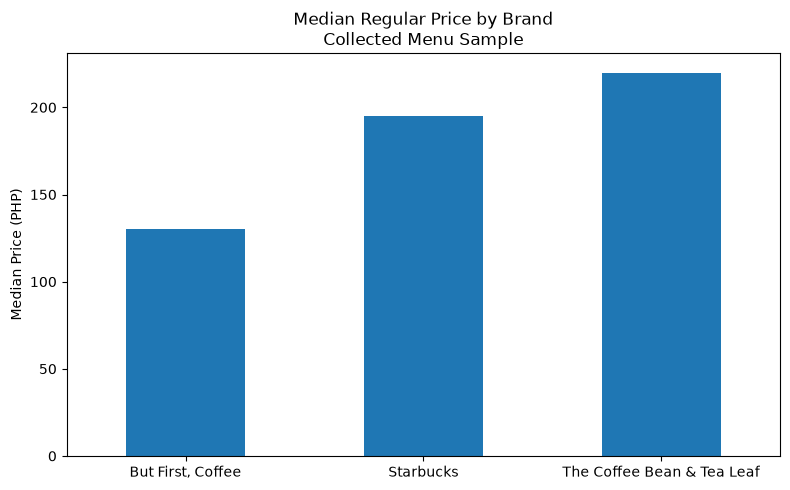

In [7]:
median_prices = (
    menu_prices
    .groupby("brand")
    ["regular_price_php"]
    .median()
    .sort_values()
)

ax = median_prices.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title(
    "Median Regular Price by Brand\nCollected Menu Sample"
)

ax.set_xlabel("")
ax.set_ylabel("Median Price (PHP)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

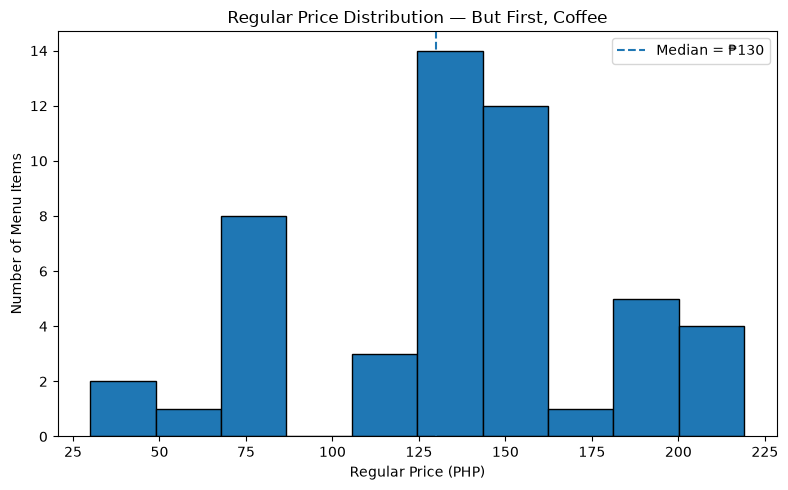

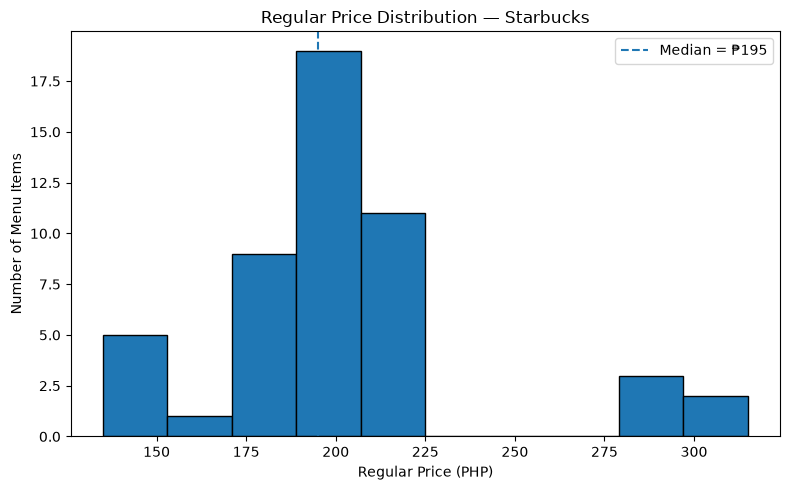

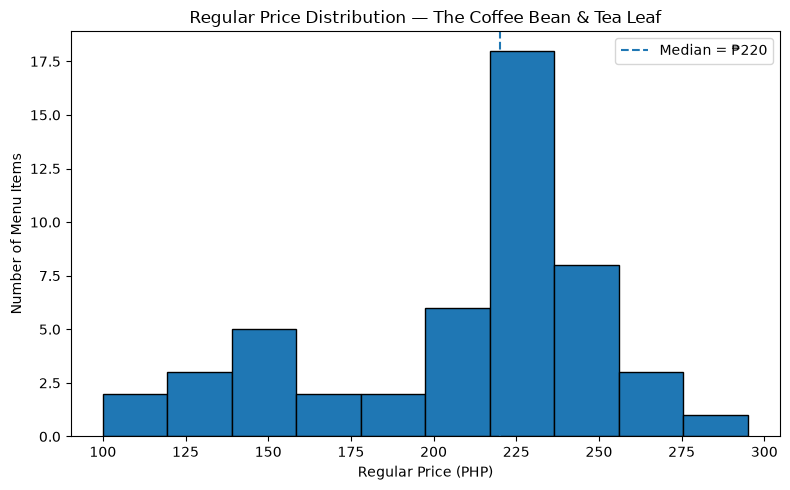

In [8]:
brands = [
    "But First, Coffee",
    "Starbucks",
    "The Coffee Bean & Tea Leaf"
]

for brand in brands:

    brand_prices = menu_prices.loc[
        menu_prices["brand"] == brand,
        "regular_price_php"
    ]

    plt.figure(figsize=(8, 5))

    plt.hist(
        brand_prices,
        bins=10,
        edgecolor="black"
    )

    plt.axvline(
        brand_prices.median(),
        linestyle="--",
        label=f"Median = ₱{brand_prices.median():.0f}"
    )

    plt.title(
        f"Regular Price Distribution — {brand}"
    )

    plt.xlabel("Regular Price (PHP)")
    plt.ylabel("Number of Menu Items")

    plt.legend()
    plt.tight_layout()

    plt.show()

In [9]:
price_distribution_summary = (
    menu_prices
    .groupby("brand")
    ["regular_price_php"]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .round(2)
)

price_distribution_summary

,count,mean,std,min,25%,50%,75%,max
brand,,,,,,,,
"But First, Coffee",50.0,134.42,47.67,30.0,116.0,130.0,150.0,219.0
Starbucks,50.0,201.70,39.94,135.0,185.0,195.0,210.0,315.0
The Coffee Bean & Tea Leaf,50.0,209.70,43.93,100.0,185.0,220.0,235.0,295.0


In [10]:
price_iqr = (
    menu_prices
    .groupby("brand")
    ["regular_price_php"]
    .quantile([0.25, 0.75])
    .unstack()
)

price_iqr.columns = ["Q1", "Q3"]

price_iqr["IQR"] = (
    price_iqr["Q3"]
    - price_iqr["Q1"]
)

price_iqr.round(2)

,Q1,Q3,IQR
brand,,,
"But First, Coffee",116.0,150.0,34.0
Starbucks,185.0,210.0,25.0
The Coffee Bean & Tea Leaf,185.0,235.0,50.0


In [11]:
menu_composition = pd.crosstab(
    menu_prices["brand"],
    menu_prices["product_class"],
    margins=True
)

menu_composition

product_class,Add-on,Beverage,Food,All
brand,,,,
"But First, Coffee",2,45,3,50
Starbucks,0,38,12,50
The Coffee Bean & Tea Leaf,0,39,11,50
All,2,122,26,150


In [12]:
menu_composition_pct = pd.crosstab(
    menu_prices["brand"],
    menu_prices["product_class"],
    normalize="index"
).mul(100).round(2)

menu_composition_pct

product_class,Add-on,Beverage,Food
brand,,,
"But First, Coffee",4.0,90.0,6.0
Starbucks,0.0,76.0,24.0
The Coffee Bean & Tea Leaf,0.0,78.0,22.0


In [13]:
beverage_prices = (
    menu_prices[
        menu_prices["product_class"] == "Beverage"
    ]
    .copy()
)

beverage_price_summary = (
    beverage_prices
    .groupby("brand")
    ["regular_price_php"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(2)
)

beverage_price_summary

,count,mean,median,std,min,max
brand,,,,,,
"But First, Coffee",45,141.91,130.0,42.08,69,219
Starbucks,38,196.84,195.0,15.40,140,220
The Coffee Bean & Tea Leaf,39,223.97,225.0,26.39,150,270


In [14]:
matched_price_matrix = (
    matched_family_prices
    .pivot(
        index="comparable_product_family",
        columns="brand",
        values="representative_price_php"
    )
)

matched_price_matrix

brand,"But First, Coffee",Starbucks,The Coffee Bean & Tea Leaf
comparable_product_family,,,
Americano,130.0,175.0,185.0
Cafe Latte,150.0,185.0,187.5
Caramel Macchiato,130.0,210.0,245.0
Matcha Latte,130.0,190.0,225.0
Mocha,150.0,205.0,220.0


In [15]:
matched_price_gaps = (
    matched_price_matrix.copy()
)

matched_price_gaps["BFC_vs_Starbucks_Gap_Pct"] = (
    (
        matched_price_gaps["But First, Coffee"]
        / matched_price_gaps["Starbucks"]
    ) - 1
) * 100

matched_price_gaps["BFC_vs_CBTL_Gap_Pct"] = (
    (
        matched_price_gaps["But First, Coffee"]
        / matched_price_gaps[
            "The Coffee Bean & Tea Leaf"
        ]
    ) - 1
) * 100

matched_price_gaps[
    [
        "BFC_vs_Starbucks_Gap_Pct",
        "BFC_vs_CBTL_Gap_Pct"
    ]
].round(1)

brand,BFC_vs_Starbucks_Gap_Pct,BFC_vs_CBTL_Gap_Pct
comparable_product_family,,
Americano,-25.7,-29.7
Cafe Latte,-18.9,-20.0
Caramel Macchiato,-38.1,-46.9
Matcha Latte,-31.6,-42.2
Mocha,-26.8,-31.8


In [16]:
average_matched_gap = pd.DataFrame({
    "competitor": [
        "Starbucks",
        "The Coffee Bean & Tea Leaf"
    ],
    "average_gap_pct": [
        matched_price_gaps[
            "BFC_vs_Starbucks_Gap_Pct"
        ].mean(),

        matched_price_gaps[
            "BFC_vs_CBTL_Gap_Pct"
        ].mean()
    ]
})

average_matched_gap.round(1)

,competitor,average_gap_pct
0,Starbucks,-28.2
1,The Coffee Bean & Tea Leaf,-34.1


## Preliminary Pricing Interpretation

The overall menu-price distributions provide descriptive context but are affected by differences in product composition across the three brands.

For stronger competitive benchmarking, five directly comparable product families were analyzed using one representative median price per brand and product family.

Across these matched products, But First, Coffee's observed regular prices were consistently below Starbucks and The Coffee Bean & Tea Leaf.

This establishes a clear affordability position within the collected competitive sample.

However, a lower competitive price does not automatically imply that prices should be increased. A revenue-management recommendation would require consideration of transaction volume, price elasticity, product mix, customer response, variable cost, and contribution margin.

The pricing gaps therefore identify potential areas for further revenue investigation rather than proving that a price increase would improve profitability.

In [17]:
price_outlier_records = []

for brand in brands:

    brand_data = menu_prices[
        menu_prices["brand"] == brand
    ].copy()

    q1 = brand_data["regular_price_php"].quantile(0.25)
    q3 = brand_data["regular_price_php"].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    brand_data["lower_bound"] = lower_bound
    brand_data["upper_bound"] = upper_bound

    outliers = brand_data[
        (brand_data["regular_price_php"] < lower_bound)
        | (brand_data["regular_price_php"] > upper_bound)
    ]

    price_outlier_records.append(outliers)

price_outliers = pd.concat(
    price_outlier_records,
    ignore_index=True
)

print(
    "Potential price outliers:",
    len(price_outliers)
)

price_outliers[
    [
        "brand",
        "branch",
        "product",
        "product_class",
        "regular_price_php",
        "lower_bound",
        "upper_bound"
    ]
].sort_values(
    ["brand", "regular_price_php"]
)

Potential price outliers: 17


,brand,branch,product,product_class,regular_price_php,lower_bound,upper_bound
5,"But First, Coffee",Malingap Street,Toppers 50mL,Add-on,30,65.0,201.0
6,"But First, Coffee",Malingap Street,Milk 40mL,Add-on,30,65.0,201.0
4,"But First, Coffee",Malingap Street,Chocolate Chip Cookie,Food,60,65.0,201.0
0,"But First, Coffee",Malingap Street,Golden Hour 1L,Beverage,219,65.0,201.0
1,"But First, Coffee",Malingap Street,Berry Me 1L,Beverage,219,65.0,201.0
2,"But First, Coffee",Malingap Street,Tres Leches 1L,Beverage,219,65.0,201.0
3,"But First, Coffee",Malingap Street,Autumn Kiss 1L,Beverage,219,65.0,201.0
12,Starbucks,6750 Building,Green Tea Mochi Doughnut,Food,135,147.5,247.5
13,Starbucks,6750 Building,Strawberry Mochi Doughnut,Food,135,147.5,247.5
14,Starbucks,6750 Building,Latte Mochi Doughnut,Food,135,147.5,247.5


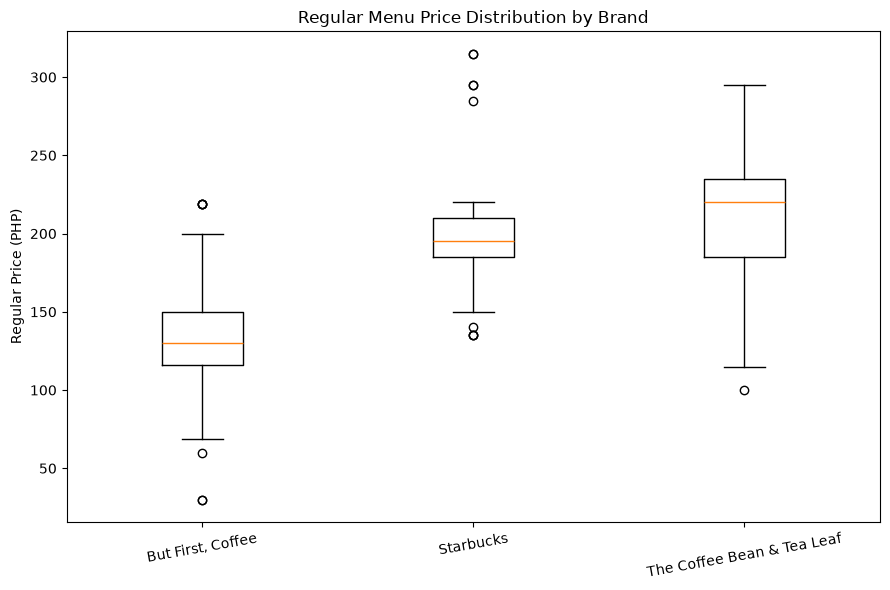

In [18]:
price_groups = [
    menu_prices.loc[
        menu_prices["brand"] == brand,
        "regular_price_php"
    ]
    for brand in brands
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    price_groups,
    tick_labels=brands
)

plt.title(
    "Regular Menu Price Distribution by Brand"
)

plt.ylabel("Regular Price (PHP)")
plt.xlabel("")

plt.xticks(rotation=10)
plt.tight_layout()

plt.show()

In [19]:
promotion_summary = (
    menu_prices
    .groupby("brand")
    .agg(
        menu_observations=("product", "count"),
        promotional_observations=("is_promo", "sum")
    )
)

promotion_summary["promotion_coverage_pct"] = (
    promotion_summary["promotional_observations"]
    / promotion_summary["menu_observations"]
    * 100
)

promotion_summary.round(2)

,menu_observations,promotional_observations,promotion_coverage_pct
brand,,,
"But First, Coffee",50,45,90.0
Starbucks,50,0,0.0
The Coffee Bean & Tea Leaf,50,0,0.0


In [20]:
bfc_promotions = (
    menu_prices[
        (menu_prices["brand"] == "But First, Coffee")
        & (menu_prices["is_promo"])
    ]
    .copy()
)

bfc_promotions["discount_pct"].describe()

count    4.500000e+01
mean     2.000000e+01
std      1.514882e-15
min      2.000000e+01
25%      2.000000e+01
50%      2.000000e+01
75%      2.000000e+01
max      2.000000e+01
Name: discount_pct, dtype: float64

In [21]:
bfc_promotions["discount_pct"].value_counts()

discount_pct
20.0    37
20.0     4
20.0     4
Name: count, dtype: int64

In [22]:
observed_discount_rate = (
    bfc_promotions["discount_pct"].median()
    / 100
)

required_volume_multiplier = (
    1 / (1 - observed_discount_rate)
)

required_volume_uplift_pct = (
    required_volume_multiplier - 1
) * 100

print(
    f"Observed discount rate: "
    f"{observed_discount_rate:.0%}"
)

print(
    f"Revenue-neutral volume multiplier: "
    f"{required_volume_multiplier:.2f}x"
)

print(
    f"Required volume uplift: "
    f"{required_volume_uplift_pct:.1f}%"
)

Observed discount rate: 20%
Revenue-neutral volume multiplier: 1.25x
Required volume uplift: 25.0%


In [23]:
discount_scenarios = pd.DataFrame({
    "discount_pct": [
        5, 10, 15, 20, 25, 30
    ]
})

discount_scenarios[
    "price_retained_pct"
] = (
    100
    - discount_scenarios["discount_pct"]
)

discount_scenarios[
    "required_volume_multiplier"
] = (
    1
    / (
        discount_scenarios[
            "price_retained_pct"
        ] / 100
    )
)

discount_scenarios[
    "required_volume_uplift_pct"
] = (
    (
        discount_scenarios[
            "required_volume_multiplier"
        ] - 1
    ) * 100
)

discount_scenarios.round(2)

,discount_pct,price_retained_pct,required_volume_multiplier,required_volume_uplift_pct
0,5,95,1.05,5.26
1,10,90,1.11,11.11
2,15,85,1.18,17.65
3,20,80,1.25,25.00
4,25,75,1.33,33.33
5,30,70,1.43,42.86


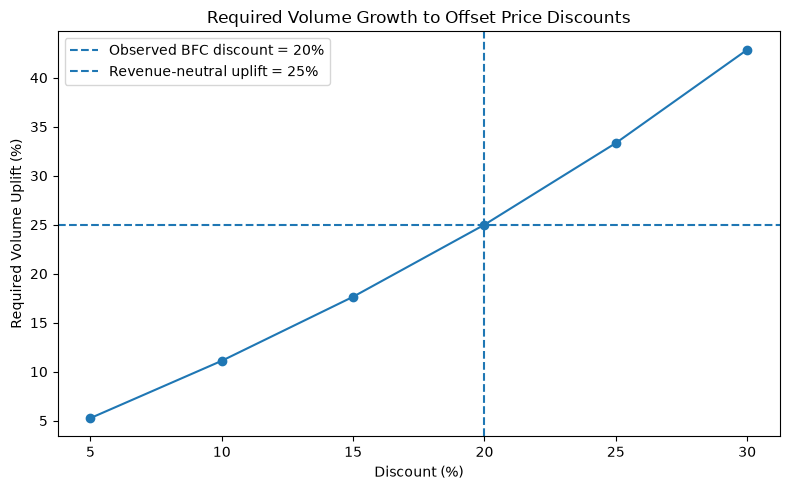

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    discount_scenarios["discount_pct"],
    discount_scenarios[
        "required_volume_uplift_pct"
    ],
    marker="o"
)

plt.axvline(
    20,
    linestyle="--",
    label="Observed BFC discount = 20%"
)

plt.axhline(
    25,
    linestyle="--",
    label="Revenue-neutral uplift = 25%"
)

plt.title(
    "Required Volume Growth to Offset Price Discounts"
)

plt.xlabel("Discount (%)")
plt.ylabel("Required Volume Uplift (%)")

plt.legend()
plt.tight_layout()

plt.show()

## Promotional Pricing Interpretation

In the collected menu snapshot, 45 of 50 But First, Coffee observations contained a promotional price, representing 90% observed promotion coverage. All observed promotional prices reflected a 20% reduction from their corresponding regular prices.

A 20% price reduction requires approximately 25% additional unit or transaction volume merely to maintain the same gross revenue, assuming the product mix remains constant.

This does not imply that the observed promotions are unprofitable. Transaction volumes, incremental demand, customer acquisition, repeat purchases, product costs, and contribution margins are unavailable.

The analysis therefore identifies an important revenue-management question:

**Do promotional products generate at least enough incremental transaction volume and contribution to compensate for the reduction in selling price?**

With internal POS data, this could be evaluated by comparing promotional and non-promotional periods using transaction volume, average transaction value, units per transaction, product mix, and contribution margin.

In [25]:
review_sample = (
    reviews["brand"]
    .value_counts()
    .rename_axis("brand")
    .reset_index(name="reviews")
)

review_sample["sample_share_pct"] = (
    review_sample["reviews"]
    / review_sample["reviews"].sum()
    * 100
)

review_sample.round(2)

,brand,reviews,sample_share_pct
0,Starbucks,108,38.30
1,"But First, Coffee",104,36.88
2,The Coffee Bean & Tea Leaf,70,24.82


In [26]:
theme_columns = [
    column
    for column in reviews.columns
    if column.startswith("theme_")
    and column not in {
        "theme_original",
        "theme_list",
        "theme_standard_list",
        "theme_count"
    }
]

overall_theme_prevalence = (
    reviews[theme_columns]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
    .rename("prevalence_pct")
    .reset_index()
    .rename(columns={"index": "theme"})
)

overall_theme_prevalence

,theme,prevalence_pct
0,theme_taste,30.85
1,theme_packaging,19.50
2,theme_order_accuracy,14.89
3,theme_customization,13.12
4,theme_consistency,9.57
5,theme_missing_item,7.80
6,theme_portion,7.80
7,theme_value,7.09
8,theme_service,4.61
9,theme_add_on,4.61


In [27]:
theme_prevalence_by_brand = (
    reviews
    .groupby("brand")[theme_columns]
    .mean()
    .mul(100)
    .round(2)
    .T
)

theme_prevalence_by_brand

brand,"But First, Coffee",Starbucks,The Coffee Bean & Tea Leaf
theme_add_on,3.85,8.33,0.00
theme_availability,0.00,1.85,5.71
theme_coffee_strength,1.92,0.00,1.43
theme_consistency,13.46,7.41,7.14
theme_customization,8.65,22.22,5.71
theme_delivery,0.96,0.93,0.00
theme_food_quality,0.96,2.78,10.00
theme_loyalty,2.88,0.00,2.86
theme_missing_add_on,0.96,0.00,0.00
theme_missing_item,3.85,12.04,7.14


In [28]:
dimension_columns = [
    column
    for column in reviews.columns
    if column.startswith("dimension_")
]

dimension_prevalence_eda = (
    reviews
    .groupby("brand")[dimension_columns]
    .mean()
    .mul(100)
    .round(2)
    .T
)

dimension_prevalence_eda

brand,"But First, Coffee",Starbucks,The Coffee Bean & Tea Leaf
dimension_product_quality,50.00,20.37,37.14
dimension_order_execution,15.38,32.41,27.14
dimension_customization_addons,12.50,28.70,5.71
dimension_packaging,19.23,16.67,24.29
dimension_value_portion,19.23,6.48,11.43
dimension_service_delivery,7.69,8.33,2.86
dimension_availability_consistency,13.46,7.41,12.86
dimension_loyalty_experience,3.85,0.00,7.14


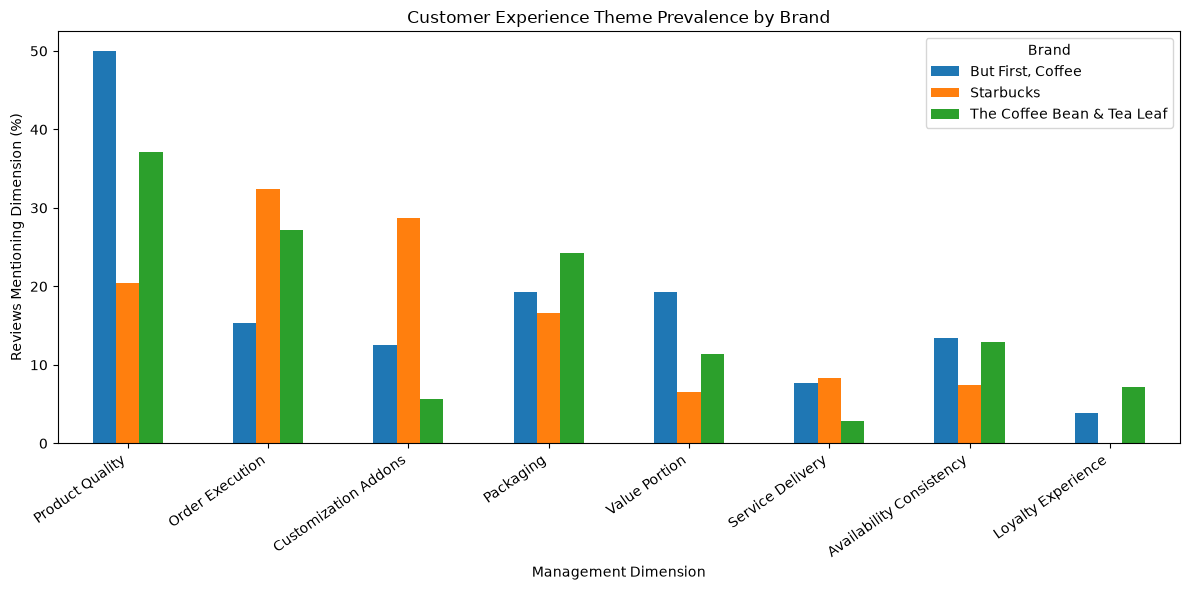

In [29]:
dimension_chart = (
    dimension_prevalence_eda
    .copy()
)

dimension_chart.index = (
    dimension_chart.index
    .str.replace(
        "dimension_",
        "",
        regex=False
    )
    .str.replace("_", " ")
    .str.title()
)

dimension_chart.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Customer Experience Theme Prevalence by Brand"
)

plt.xlabel("Management Dimension")
plt.ylabel("Reviews Mentioning Dimension (%)")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(title="Brand")
plt.tight_layout()

plt.show()

In [30]:
menu_prices["discount_pct_rounded"] = (
    menu_prices["discount_pct"]
    .round(2)
)

bfc_discount_distribution = (
    menu_prices.loc[
        (menu_prices["brand"] == "But First, Coffee")
        & (menu_prices["is_promo"]),
        "discount_pct_rounded"
    ]
    .value_counts()
    .sort_index()
)

bfc_discount_distribution

discount_pct_rounded
20.0    45
Name: count, dtype: int64

## Price Outlier Assessment

Seventeen menu-price observations were identified as statistical outliers using the 1.5 × IQR rule.

Inspection indicated that these observations represent commercially plausible menu items rather than obvious data-entry errors. Examples include low-priced add-ons and bakery products, premium food items, and larger-format beverages.

The observations were therefore retained.

This demonstrates an important distinction between statistical and business outliers: an observation may be unusual relative to a distribution while still representing a legitimate commercial product.

In [31]:
review_polarity_audit = reviews[
    [
        "brand",
        "branch",
        "review_text_clean",
        "theme_original"
    ]
].copy()

review_polarity_audit.sample(
    30,
    random_state=42
)

,brand,branch,review_text_clean,theme_original
92,"But First, Coffee",Malingap Street,Customer believed ordered coffee drinks contained no espresso shot.,taste/order accuracy
93,"But First, Coffee",Quirino Highway,Customer praised coffee and fast preparation/delivery.,speed/taste
179,Starbucks,Metroplaza Dagupan,Drink cover was not sealed and straw was missing.,packaging
124,"But First, Coffee",San Pablo Maharlika,Sea-salt latte received very strong positive feedback.,taste
261,The Coffee Bean & Tea Leaf,Centrio Mall,Repeat customer strongly praised the branch and Original Mocha.,loyalty/taste
233,The Coffee Bean & Tea Leaf,Bel-Air,Cup holder was missing.,packaging
77,"But First, Coffee",San Isidro Angono,Customer said the drink was heavily taped and difficult to open.,packaging
9,"But First, Coffee",Malingap Street,Not a single shot was in my drinks.,order accuracy/coffee strength
251,The Coffee Bean & Tea Leaf,Robinsons Naga,Customer praised baristas for fulfilling a request.,service/customization
264,The Coffee Bean & Tea Leaf,Centrio Mall,Matcha latte tasted different from prior orders.,taste/consistency


In [32]:
positive_terms = [
    "love",
    "good",
    "great",
    "best",
    "delicious",
    "excellent",
    "perfect",
    "nice",
    "favorite",
    "favourite",
    "satisfied",
    "recommend"
]

positive_pattern = "|".join(
    positive_terms
)

potential_positive_reviews = reviews[
    reviews["review_text_clean"]
    .str.lower()
    .str.contains(
        positive_pattern,
        na=False,
        regex=True
    )
][
    [
        "brand",
        "review_text_clean",
        "theme_original"
    ]
]

print(
    "Potential positive-language reviews:",
    len(potential_positive_reviews)
)

potential_positive_reviews.head(30)

Potential positive-language reviews: 16


,brand,review_text_clean,theme_original
2,"But First, Coffee",I love but first coffee i always buy coffee there but this branch not good or standard of how ma...,consistency
6,"But First, Coffee",Great drink + followed my special requests also,customization/service
16,"But First, Coffee",The barista here makes my drink taste way better than other branches — perfectly balanced and so...,consistency/taste
20,"But First, Coffee",Dissatisfied :( puro yelo lang,portion/value
31,The Coffee Bean & Tea Leaf,Not very good packaging. Received my order almost half,packaging/portion
43,"But First, Coffee",coffee is not as good as it was before,taste/consistency
48,"But First, Coffee",Coffee is not too strong. Went well with the condensed milk after mixing. Great beverage to keep...,taste/occasion
55,"But First, Coffee",puro yelo lang di ka ma satisfied,portion/value
64,Starbucks,Ordered hot chocolate and cinnamon danish; prepared ahead of time and great packaging.,speed/packaging
69,The Coffee Bean & Tea Leaf,The Original Mocha had the perfect blend.,taste


In [33]:
negative_terms = [
    "bad",
    "wrong",
    "missing",
    "poor",
    "disappointed",
    "disappointing",
    "watery",
    "bland",
    "cold",
    "spilled",
    "leak",
    "lacks",
    "not good",
    "too sweet",
    "too small",
    "expensive"
]

negative_pattern = "|".join(
    negative_terms
)

potential_negative_reviews = reviews[
    reviews["review_text_clean"]
    .str.lower()
    .str.contains(
        negative_pattern,
        na=False,
        regex=True
    )
][
    [
        "brand",
        "review_text_clean",
        "theme_original"
    ]
]

print(
    "Potential negative-language reviews:",
    len(potential_negative_reviews)
)

potential_negative_reviews.head(30)

Potential negative-language reviews: 78


,brand,review_text_clean,theme_original
1,"But First, Coffee",Lacks espresso. Gatas lang yung nalalasahan,taste/coffee strength
2,"But First, Coffee",I love but first coffee i always buy coffee there but this branch not good or standard of how ma...,consistency
3,"But First, Coffee","The cap was not properly sealed, and since it was made of paper, the spilled liquid was absorbed...",packaging
5,"But First, Coffee",I ordered 2 different drinks. They gave me 2 cups of iced choco only instead of iced brown sugar...,order accuracy
15,"But First, Coffee","the branch gave me wrong order, my order was matcha latte but gavee me a latte.",order accuracy
17,"But First, Coffee",blueberry cheese was too small for the price,value/portion
19,"But First, Coffee",when i received my order one of tge drinks was spilled out. the glass was broken,packaging
25,Starbucks,they gave me the wrong order. asked for chocolate but gave me caramel instead.,order accuracy
26,Starbucks,I ordered Hot for Hazelnut Mocha Macchiato but I received cold... remarks is not followed.,order accuracy/customization
37,The Coffee Bean & Tea Leaf,Too sweet,taste


In [34]:
positive_mask = (
    reviews["review_text_clean"]
    .str.lower()
    .str.contains(
        positive_pattern,
        na=False,
        regex=True
    )
)

negative_mask = (
    reviews["review_text_clean"]
    .str.lower()
    .str.contains(
        negative_pattern,
        na=False,
        regex=True
    )
)

polarity_screen = pd.DataFrame({
    "positive_language": positive_mask,
    "negative_language": negative_mask
})

polarity_screen["screening_class"] = np.select(
    [
        positive_mask & ~negative_mask,
        negative_mask & ~positive_mask,
        positive_mask & negative_mask
    ],
    [
        "Potential Positive",
        "Potential Negative",
        "Potential Mixed"
    ],
    default="Unclassified"
)

polarity_screen[
    "screening_class"
].value_counts()

screening_class
Unclassified          189
Potential Negative     77
Potential Positive     15
Potential Mixed         1
Name: count, dtype: int64

In [35]:
reviews["polarity_screen"] = (
    polarity_screen["screening_class"]
)

polarity_examples = (
    reviews[
        [
            "brand",
            "review_text_clean",
            "theme_original",
            "polarity_screen"
        ]
    ]
    .sort_values(
        "polarity_screen"
    )
)

polarity_examples.head(40)

,brand,review_text_clean,theme_original,polarity_screen
2,"But First, Coffee",I love but first coffee i always buy coffee there but this branch not good or standard of how ma...,consistency,Potential Mixed
140,"But First, Coffee",One Auro Choco Strawberry was missing.,missing item,Potential Negative
151,Starbucks,Products were missing from the order.,missing item,Potential Negative
156,Starbucks,Wrong order was provided.,order accuracy,Potential Negative
54,"But First, Coffee",ONE OF THE COFFEE SPILLED HALF OF ITS CONTENT AS THE COVER WAS NOT CLOSED PROPERLY,packaging,Potential Negative
158,Starbucks,"Drink was ice-heavy, underfilled and poorly sealed.",portion/packaging,Potential Negative
52,"But First, Coffee",Doesnt taste like the usual spanish coffee. Too sweet,taste/consistency,Potential Negative
166,Starbucks,Poor sealing caused coffee to spill and wet the bag.,packaging,Potential Negative
169,Starbucks,Whipped cream and caramel syrup were missing.,add-on,Potential Negative
174,Starbucks,Vanilla sweet cream cold brew lacked sweet cream.,add-on,Potential Negative


In [36]:
polarity_coverage = (
    reviews["polarity_screen"]
    .value_counts()
    .rename_axis("screening_class")
    .reset_index(name="reviews")
)

polarity_coverage["percentage"] = (
    polarity_coverage["reviews"]
    / len(reviews)
    * 100
)

polarity_coverage.round(2)

,screening_class,reviews,percentage
0,Unclassified,189,67.02
1,Potential Negative,77,27.30
2,Potential Positive,15,5.32
3,Potential Mixed,1,0.35


In [38]:
theme_cooccurrence = (
    reviews[theme_columns]
    .T
    .dot(
        reviews[theme_columns]
    )
)

# Set diagonal to zero using pandas
for theme in theme_cooccurrence.index:
    theme_cooccurrence.loc[
        theme,
        theme
    ] = 0

theme_cooccurrence

,theme_add_on,theme_availability,theme_coffee_strength,theme_consistency,theme_customization,theme_delivery,theme_food_quality,theme_loyalty,theme_missing_add_on,theme_missing_item,theme_occasion,theme_order_accuracy,theme_order_identification,theme_packaging,theme_packaging_accessories,theme_portion,theme_portion_consistency,theme_positive,theme_quality,theme_service,theme_size_accuracy,theme_speed,theme_taste,theme_temperature,theme_value
theme_add_on,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1
theme_availability,0,0,0,2,1,0,2,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
theme_coffee_strength,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0
theme_consistency,0,2,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,17,0,1
theme_customization,2,1,0,2,0,0,0,0,0,0,0,3,0,0,0,2,0,0,0,5,0,0,5,0,0
theme_delivery,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
theme_food_quality,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1
theme_loyalty,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,2,0,1
theme_missing_add_on,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
theme_missing_item,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [39]:
theme_pairs = []

for i in range(
    len(theme_cooccurrence.columns)
):
    for j in range(
        i + 1,
        len(theme_cooccurrence.columns)
    ):

        theme_a = (
            theme_cooccurrence.columns[i]
        )

        theme_b = (
            theme_cooccurrence.columns[j]
        )

        count = (
            theme_cooccurrence.iloc[i, j]
        )

        if count > 0:
            theme_pairs.append({
                "theme_1": theme_a,
                "theme_2": theme_b,
                "cooccurrence_count": count
            })

theme_pairs = (
    pd.DataFrame(theme_pairs)
    .sort_values(
        "cooccurrence_count",
        ascending=False
    )
    .reset_index(drop=True)
)

theme_pairs.head(20)

,theme_1,theme_2,cooccurrence_count
0,theme_consistency,theme_taste,17
1,theme_portion,theme_value,8
2,theme_taste,theme_value,7
3,theme_customization,theme_service,5
4,theme_customization,theme_taste,5
5,theme_portion,theme_taste,4
6,theme_packaging,theme_taste,4
7,theme_quality,theme_taste,3
8,theme_packaging,theme_service,3
9,theme_order_accuracy,theme_taste,3


In [40]:
top_5_theme_prevalence = (
    overall_theme_prevalence
    .head(5)
    .copy()
)

top_5_theme_prevalence

,theme,prevalence_pct
0,theme_taste,30.85
1,theme_packaging,19.50
2,theme_order_accuracy,14.89
3,theme_customization,13.12
4,theme_consistency,9.57


## Preliminary Customer Experience Interpretation

Customer-experience analysis was based on theme prevalence rather than raw theme counts because the number of collected reviews differs across brands.

Across the full review sample, taste was the most frequently identified theme, followed by packaging, order accuracy, customization, and consistency.

The competitive profiles differ:

- But First, Coffee showed particularly high prevalence of product-quality and value/portion themes.
- Starbucks showed comparatively high prevalence of order-execution and customization/add-on themes.
- The Coffee Bean & Tea Leaf showed comparatively high prevalence of packaging and product-quality themes.

These results indicate what customers discussed within the sampled reviews. They do not, by themselves, establish whether the discussion was positive or negative.

Review-text polarity is therefore evaluated separately before any positive-versus-negative customer-experience conclusions are made.

## Polarity Screening Assessment

An exploratory keyword-based polarity screen was evaluated to determine whether customer reviews could be classified as positive or negative.

The initial screen was not adopted as the final sentiment method because:

- approximately two-thirds of reviews remained unclassified;
- simple substring matching generated false-positive classifications;
- negation could reverse the meaning of otherwise positive words;
- some reviews contained mixed experiences;
- several reviews were paraphrased rather than verbatim customer text.

The keyword screen is therefore retained only as a methodological diagnostic and is not used as the final customer-sentiment measure.

A more conservative rule-based classification is developed using explicit review language and experience-theme evidence.

In [41]:
strong_negative_themes = {
    "missing_item",
    "missing_add_on",
    "size_accuracy"
}

negative_theme_columns = [
    f"theme_{theme}"
    for theme in strong_negative_themes
    if f"theme_{theme}" in reviews.columns
]

reviews["strong_negative_theme"] = (
    reviews[negative_theme_columns]
    .max(axis=1)
)

reviews[
    "strong_negative_theme"
].value_counts()

strong_negative_theme
0    253
1     29
Name: count, dtype: int64

In [42]:
explicit_negative_patterns = [
    r"\bwrong\b",
    r"\bmissing\b",
    r"\bpoor\b",
    r"\bwatery\b",
    r"\bbland\b",
    r"\bspilled\b",
    r"\bleak(?:ed|ing)?\b",
    r"\bdisappointed\b",
    r"\bdissatisfied\b",
    r"\bunpleasant\b",
    r"\bburnt\b",
    r"\bstale\b",
    r"\bnot good\b",
    r"\bnot properly\b",
    r"\bnot followed\b",
    r"\bnot delivered\b",
    r"\btoo sweet\b",
    r"\btoo small\b",
    r"\bunderfilled\b",
    r"\bweaker than before\b",
    r"\bdifficult to open\b",
    r"\bdid not do my request\b",
    r"\bignored\b"
]

negative_regex = "|".join(
    explicit_negative_patterns
)

reviews["explicit_negative_language"] = (
    reviews["review_text_clean"]
    .str.lower()
    .str.contains(
        negative_regex,
        regex=True,
        na=False
    )
    .astype(int)
)

reviews[
    "explicit_negative_language"
].value_counts()

explicit_negative_language
0    186
1     96
Name: count, dtype: int64

In [43]:
explicit_positive_patterns = [
    r"\blove\b",
    r"\bliked\b",
    r"\bpraised\b",
    r"\bgreat\b",
    r"\bexcellent\b",
    r"\bperfect\b",
    r"\bperfectly\b",
    r"\bdelicious\b",
    r"\bfavorite\b",
    r"\bfavourite\b",
    r"\bwell packed\b",
    r"\bwell made\b",
    r"\bwell prepared\b",
    r"\btasted good\b",
    r"\bgood coffee\b",
    r"\bstrongly praised\b",
    r"\bpositive feedback\b"
]

positive_regex = "|".join(
    explicit_positive_patterns
)

reviews["explicit_positive_language"] = (
    reviews["review_text_clean"]
    .str.lower()
    .str.contains(
        positive_regex,
        regex=True,
        na=False
    )
    .astype(int)
)

reviews[
    "explicit_positive_language"
].value_counts()

explicit_positive_language
0    244
1     38
Name: count, dtype: int64

In [44]:
negative_evidence = (
    (reviews["explicit_negative_language"] == 1)
    | (reviews["strong_negative_theme"] == 1)
)

positive_evidence = (
    reviews["explicit_positive_language"] == 1
)

reviews["experience_polarity"] = np.select(
    [
        positive_evidence & ~negative_evidence,
        negative_evidence & ~positive_evidence,
        positive_evidence & negative_evidence
    ],
    [
        "Positive",
        "Negative",
        "Mixed"
    ],
    default="Unclear"
)

reviews[
    "experience_polarity"
].value_counts()

experience_polarity
Unclear     135
Negative    109
Positive     35
Mixed         3
Name: count, dtype: int64

In [45]:
polarity_audit_sample = (
    reviews[
        [
            "brand",
            "review_text_clean",
            "theme_original",
            "experience_polarity"
        ]
    ]
    .groupby(
        "experience_polarity",
        group_keys=False
    )
    .apply(
        lambda x:
        x.sample(
            min(10, len(x)),
            random_state=42
        ),
        include_groups=False
    )
)

polarity_audit_sample

,brand,review_text_clean,theme_original
2,"But First, Coffee",I love but first coffee i always buy coffee there but this branch not good or standard of how ma...,consistency
90,"But First, Coffee",Coffee strength was liked but paid whipped-cream add-on was missing.,taste/add-on
250,The Coffee Bean & Tea Leaf,Coffee was liked but tuna sandwich was considered poor value and stale.,food quality/value
222,Starbucks,Order instructions were not followed.,customization
33,The Coffee Bean & Tea Leaf,"They did not properly lock the cup seal, which should have been quality checked since this is fo...",packaging
19,"But First, Coffee",when i received my order one of tge drinks was spilled out. the glass was broken,packaging
229,Starbucks,Customer reported receiving the wrong order.,order accuracy
194,Starbucks,Drink arrived melted and watery.,taste/temperature
204,Starbucks,Multiple drinks spilled because cups were not sealed.,packaging
113,"But First, Coffee",Cheesecake portion was considered too small for its price.,value/portion


In [46]:
polarity_summary = (
    reviews[
        "experience_polarity"
    ]
    .value_counts()
    .rename_axis(
        "experience_polarity"
    )
    .reset_index(
        name="reviews"
    )
)

polarity_summary["percentage"] = (
    polarity_summary["reviews"]
    / len(reviews)
    * 100
)

polarity_summary.round(2)

,experience_polarity,reviews,percentage
0,Unclear,135,47.87
1,Negative,109,38.65
2,Positive,35,12.41
3,Mixed,3,1.06


In [47]:
polarity_by_brand = (
    pd.crosstab(
        reviews["brand"],
        reviews["experience_polarity"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

polarity_by_brand

experience_polarity,Mixed,Negative,Positive,Unclear
brand,,,,
"But First, Coffee",1.92,28.85,17.31,51.92
Starbucks,0.00,45.37,7.41,47.22
The Coffee Bean & Tea Leaf,1.43,42.86,12.86,42.86


In [48]:
theme_pairs_clean = (
    theme_pairs.copy()
)

theme_pairs_clean["theme_1"] = (
    theme_pairs_clean["theme_1"]
    .str.replace(
        "theme_",
        "",
        regex=False
    )
    .str.replace("_", " ")
    .str.title()
)

theme_pairs_clean["theme_2"] = (
    theme_pairs_clean["theme_2"]
    .str.replace(
        "theme_",
        "",
        regex=False
    )
    .str.replace("_", " ")
    .str.title()
)

theme_pairs_clean.head(10)

,theme_1,theme_2,cooccurrence_count
0,Consistency,Taste,17
1,Portion,Value,8
2,Taste,Value,7
3,Customization,Service,5
4,Customization,Taste,5
5,Portion,Taste,4
6,Packaging,Taste,4
7,Quality,Taste,3
8,Packaging,Service,3
9,Order Accuracy,Taste,3


## Theme Co-occurrence Interpretation

Customer-experience themes frequently occur together rather than independently.

The strongest observed theme combination was taste and consistency, indicating that customers often discuss product consistency in direct connection with beverage taste.

Other notable combinations included:

- portion and value;
- taste and value;
- customization and service;
- customization and taste;
- portion and taste; and
- packaging and taste.

These relationships are commercially relevant because customer value perception is multidimensional. For example, a value concern may reflect not only price but also portion size or perceived product quality.

Likewise, product consistency can affect the customer's perception of taste across repeated purchases or different branches.

For revenue management, this means pricing decisions should not be evaluated independently from product execution. Maintaining consistent product quality, portion standards, customization accuracy, and packaging can influence whether customers perceive a given price as providing acceptable value.

## Customer Experience Polarity Method

Customer-experience polarity was classified using a conservative rule-based approach.

The classification combined:

1. explicit positive language;
2. explicit negative language; and
3. selected themes that inherently represent service failures, such as missing items, missing add-ons, and size inaccuracies.

Reviews were classified as:

- **Positive** — explicit positive evidence without identified negative evidence;
- **Negative** — explicit negative or strong failure evidence without identified positive evidence;
- **Mixed** — both positive and negative evidence;
- **Unclear** — insufficient explicit evidence to assign polarity confidently.

The method intentionally retains an Unclear category rather than forcing all reviews into positive or negative classifications.

Because the review dataset contains both customer wording and collected/paraphrased review text, polarity results are treated as descriptive indicators rather than validated sentiment scores.

In [49]:
classified_mask = (
    reviews["experience_polarity"]
    != "Unclear"
)

classified_reviews = (
    classified_mask.sum()
)

classification_coverage_pct = (
    classified_reviews
    / len(reviews)
    * 100
)

print(
    f"Classified reviews: "
    f"{classified_reviews} / {len(reviews)}"
)

print(
    f"Classification coverage: "
    f"{classification_coverage_pct:.2f}%"
)

Classified reviews: 147 / 282
Classification coverage: 52.13%


In [50]:
classified_data = (
    reviews[
        reviews["experience_polarity"]
        != "Unclear"
    ]
    .copy()
)

classified_polarity_summary = (
    classified_data[
        "experience_polarity"
    ]
    .value_counts()
    .rename_axis(
        "experience_polarity"
    )
    .reset_index(
        name="reviews"
    )
)

classified_polarity_summary[
    "share_of_classified_pct"
] = (
    classified_polarity_summary["reviews"]
    / len(classified_data)
    * 100
)

classified_polarity_summary.round(2)

,experience_polarity,reviews,share_of_classified_pct
0,Negative,109,74.15
1,Positive,35,23.81
2,Mixed,3,2.04


In [51]:
classification_coverage_by_brand = (
    reviews
    .assign(
        classified=(
            reviews[
                "experience_polarity"
            ] != "Unclear"
        )
    )
    .groupby("brand")
    ["classified"]
    .agg([
        "sum",
        "count",
        "mean"
    ])
)

classification_coverage_by_brand[
    "coverage_pct"
] = (
    classification_coverage_by_brand[
        "mean"
    ] * 100
)

classification_coverage_by_brand[
    [
        "sum",
        "count",
        "coverage_pct"
    ]
].round(2)

,sum,count,coverage_pct
brand,,,
"But First, Coffee",50,104,48.08
Starbucks,57,108,52.78
The Coffee Bean & Tea Leaf,40,70,57.14


In [52]:
classified_polarity_by_brand = (
    pd.crosstab(
        classified_data["brand"],
        classified_data[
            "experience_polarity"
        ],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

classified_polarity_by_brand

experience_polarity,Mixed,Negative,Positive
brand,,,
"But First, Coffee",4.0,60.00,36.00
Starbucks,0.0,85.96,14.04
The Coffee Bean & Tea Leaf,2.5,75.00,22.50


In [53]:
theme_by_polarity = (
    classified_data
    .groupby(
        "experience_polarity"
    )[theme_columns]
    .mean()
    .mul(100)
    .round(2)
    .T
)

theme_by_polarity

experience_polarity,Mixed,Negative,Positive
theme_add_on,33.33,4.59,0.00
theme_availability,0.00,1.83,2.86
theme_coffee_strength,0.00,0.92,0.00
theme_consistency,33.33,3.67,17.14
theme_customization,0.00,11.93,14.29
theme_delivery,0.00,0.00,0.00
theme_food_quality,33.33,3.67,0.00
theme_loyalty,0.00,0.00,8.57
theme_missing_add_on,0.00,0.92,0.00
theme_missing_item,0.00,20.18,0.00


In [54]:
top_negative_themes = (
    theme_by_polarity[
        "Negative"
    ]
    .sort_values(
        ascending=False
    )
    .head(10)
    .rename(
        "negative_prevalence_pct"
    )
    .reset_index()
    .rename(
        columns={
            "index": "theme"
        }
    )
)

top_negative_themes[
    "theme"
] = (
    top_negative_themes["theme"]
    .str.replace(
        "theme_",
        "",
        regex=False
    )
    .str.replace("_", " ")
    .str.title()
)

top_negative_themes

,theme,negative_prevalence_pct
0,Taste,23.85
1,Packaging,21.10
2,Missing Item,20.18
3,Customization,11.93
4,Order Accuracy,11.01
5,Value,7.34
6,Portion,6.42
7,Size Accuracy,5.50
8,Add On,4.59
9,Food Quality,3.67


In [55]:
top_positive_themes = (
    theme_by_polarity[
        "Positive"
    ]
    .sort_values(
        ascending=False
    )
    .head(10)
    .rename(
        "positive_prevalence_pct"
    )
    .reset_index()
    .rename(
        columns={
            "index": "theme"
        }
    )
)

top_positive_themes[
    "theme"
] = (
    top_positive_themes["theme"]
    .str.replace(
        "theme_",
        "",
        regex=False
    )
    .str.replace("_", " ")
    .str.title()
)

top_positive_themes

,theme,positive_prevalence_pct
0,Taste,57.14
1,Service,20.00
2,Consistency,17.14
3,Packaging,17.14
4,Customization,14.29
5,Loyalty,8.57
6,Speed,5.71
7,Positive,5.71
8,Value,2.86
9,Occasion,2.86


In [56]:
dimension_by_polarity = (
    classified_data
    .groupby(
        "experience_polarity"
    )[dimension_columns]
    .mean()
    .mul(100)
    .round(2)
    .T
)

dimension_by_polarity.index = (
    dimension_by_polarity.index
    .str.replace(
        "dimension_",
        "",
        regex=False
    )
    .str.replace("_", " ")
    .str.title()
)

dimension_by_polarity

experience_polarity,Mixed,Negative,Positive
Product Quality,66.67,26.61,60.00
Order Execution,0.00,36.70,0.00
Customization Addons,33.33,16.51,14.29
Packaging,0.00,21.10,17.14
Value Portion,33.33,10.09,2.86
Service Delivery,0.00,0.92,25.71
Availability Consistency,33.33,5.50,17.14
Loyalty Experience,0.00,0.00,17.14


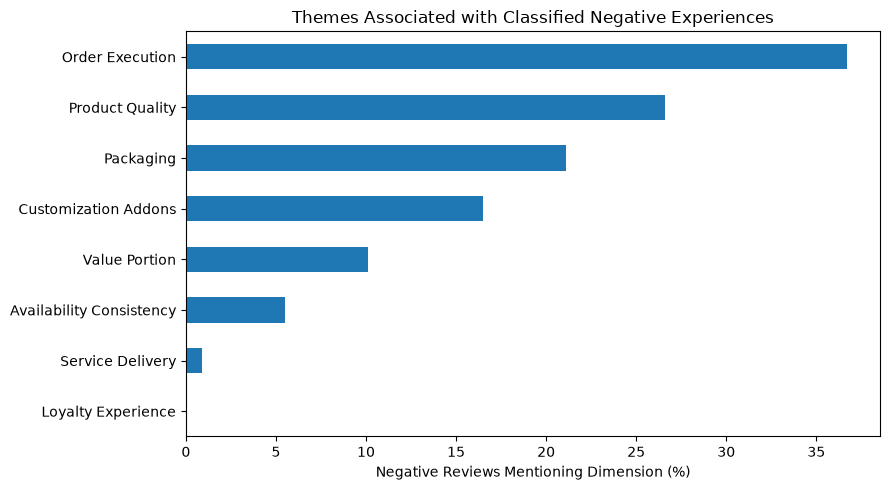

In [57]:
negative_dimensions = (
    dimension_by_polarity[
        "Negative"
    ]
    .sort_values(
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

negative_dimensions.plot(
    kind="barh"
)

plt.title(
    "Themes Associated with Classified Negative Experiences"
)

plt.xlabel(
    "Negative Reviews Mentioning Dimension (%)"
)

plt.ylabel("")

plt.tight_layout()
plt.show()

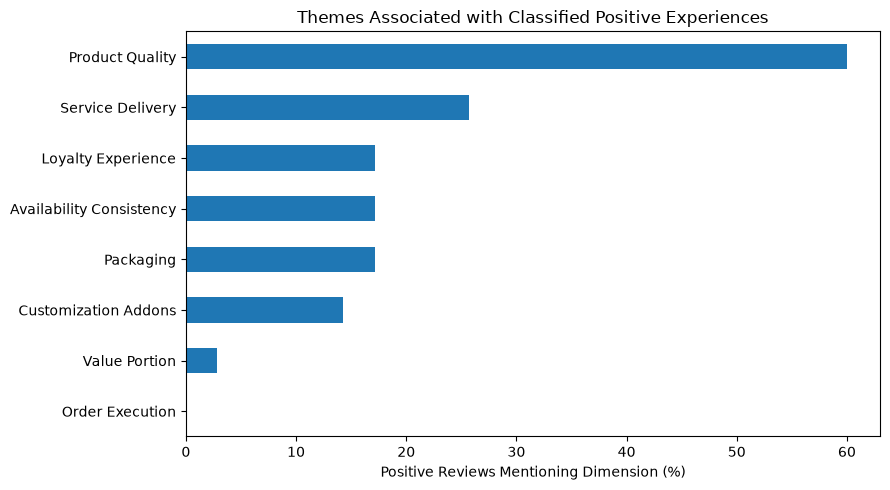

In [58]:
positive_dimensions = (
    dimension_by_polarity[
        "Positive"
    ]
    .sort_values(
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

positive_dimensions.plot(
    kind="barh"
)

plt.title(
    "Themes Associated with Classified Positive Experiences"
)

plt.xlabel(
    "Positive Reviews Mentioning Dimension (%)"
)

plt.ylabel("")

plt.tight_layout()
plt.show()

## Customer Experience Interaction Insight

Theme co-occurrence indicates that customer-experience factors should not be treated as isolated operational issues.

The strongest relationship observed was between taste and consistency. Value discussions were also frequently connected with portion and taste.

This suggests two commercially important experience systems:

### Product Consistency System
Taste ↔ Consistency ↔ Customization

### Value Perception System
Price/Value ↔ Portion ↔ Taste

For revenue management, these relationships are important because willingness to pay may depend not only on nominal price but also on whether customers receive a consistent product, appropriate portion, expected customization, and acceptable taste experience.

## RQ3 — Customer Experience Findings

A conservative rule-based polarity method successfully classified 147 of 282 reviews (52.13%). The remaining reviews were retained as Unclear rather than being forced into positive or negative categories.

Among the classified negative experiences, the most prevalent themes were:

1. Taste — 23.85%
2. Packaging — 21.10%
3. Missing Item — 20.18%
4. Customization — 11.93%
5. Order Accuracy — 11.01%

At the management-dimension level, Order Execution (36.70%) and Product Quality (26.61%) were the dimensions most frequently associated with classified negative experiences.

Among classified positive experiences, the leading themes were:

1. Taste — 57.14%
2. Service — 20.00%
3. Consistency — 17.14%
4. Packaging — 17.14%
5. Customization — 14.29%

At the management-dimension level, Product Quality (60.00%) and Service & Delivery (25.71%) were most frequently associated with classified positive experiences.

Taste therefore appears on both sides of the customer experience. This indicates that product execution can function as either a competitive strength or a customer-experience weakness depending on the individual experience.

These findings are descriptive and apply to the classified review subset. They should not be interpreted as population-level customer satisfaction rates.

In [59]:
individual_rating_summary = (
    individual_ratings["rating"]
    .describe()
    .round(2)
)

individual_rating_summary

count    13.00
mean      4.69
std       0.85
min       2.00
25%       5.00
50%       5.00
75%       5.00
max       5.00
Name: rating, dtype: float64

In [60]:
individual_rating_distribution = (
    individual_ratings["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)

individual_rating_distribution[
    "percentage"
] = (
    individual_rating_distribution["count"]
    / len(individual_ratings)
    * 100
)

individual_rating_distribution.round(2)

,rating,count,percentage
0,2,1,7.69
1,4,1,7.69
2,5,11,84.62


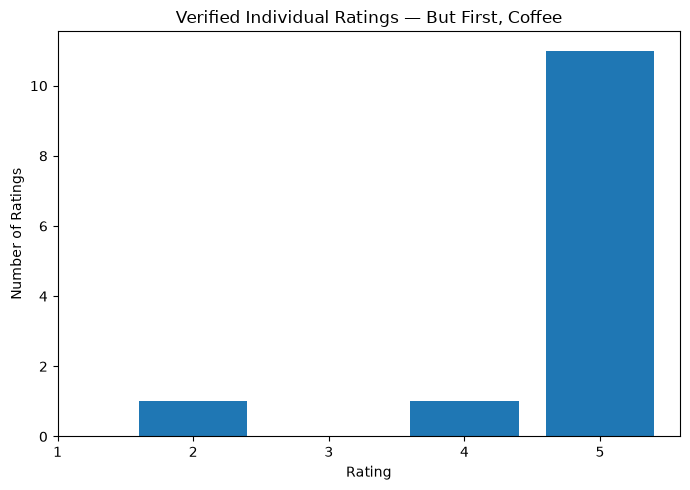

In [61]:
plt.figure(figsize=(7, 5))

rating_counts = (
    individual_ratings["rating"]
    .value_counts()
    .sort_index()
)

plt.bar(
    rating_counts.index,
    rating_counts.values
)

plt.title(
    "Verified Individual Ratings — But First, Coffee"
)

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.xticks(
    [1, 2, 3, 4, 5]
)

plt.tight_layout()
plt.show()

## Individual Rating Interpretation

Thirteen verified individual customer ratings were available for But First, Coffee across two branches.

The observed ratings are strongly concentrated at five stars. However, the sample is small and geographically limited, and the ratings were identified through indexed Google-origin review evidence.

The distribution is therefore used only as descriptive evidence.

Comparable individual-level ratings were unavailable for Starbucks and The Coffee Bean & Tea Leaf. Consequently, no cross-brand individual-rating hypothesis test will be conducted.

Branch/platform aggregate ratings are not substituted for individual ratings because they represent a different unit of analysis.

In [62]:
branch_rating_summary = (
    branch_rating_records
    .groupby("brand")
    ["aggregate_rating"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(3)
)

branch_rating_summary

,count,mean,median,std,min,max
brand,,,,,,
"But First, Coffee",19,4.995,5.0,0.023,4.9,5.0
Starbucks,17,4.994,5.0,0.024,4.9,5.0
The Coffee Bean & Tea Leaf,19,4.963,5.0,0.060,4.8,5.0


In [63]:
for brand in brands:

    brand_ratings = (
        branch_rating_records.loc[
            branch_rating_records["brand"] == brand,
            "aggregate_rating"
        ]
    )

    print(f"\n{brand}")
    print(
        brand_ratings
        .value_counts()
        .sort_index()
    )


But First, Coffee
aggregate_rating
4.9     1
5.0    18
Name: count, dtype: int64

Starbucks
aggregate_rating
4.9     1
5.0    16
Name: count, dtype: int64

The Coffee Bean & Tea Leaf
aggregate_rating
4.8     1
4.9     5
5.0    13
Name: count, dtype: int64


## Branch Aggregate Rating Context

Branch/platform aggregate ratings were analyzed using one unique record per branch-platform combination rather than repeated review-level observations.

These ratings provide descriptive competitive context only.

They are not treated as individual customer observations because each aggregate rating summarizes multiple platform ratings. Using the aggregate rating repeatedly across written-review records would artificially inflate the analytical sample and create pseudoreplication.

The observed aggregate ratings are also highly concentrated near the upper end of the rating scale, limiting their ability to distinguish customer experience across brands.

In [64]:
store_footprint[
    [
        "brand",
        "snapshot",
        "store_count_or_statement",
        "geographic_detail",
        "source_quality"
    ]
]

,brand,snapshot,store_count_or_statement,geographic_detail,source_quality
0,"But First, Coffee",2026-08-10,237+ participating branches,Nationwide Philippines,High: BPI press release naming BFC partnership
1,Starbucks,2026-07,500+ outlets,68+ cities nationwide,Medium/High: current release reproducing Rustan Coffee Corporation company boilerplate
2,The Coffee Bean & Tea Leaf,2026-08,86 locations,45 Metro Manila; 14 Cebu according to source,Medium: third-party POI dataset


In [65]:
channel_summary = (
    channels
    .groupby([
        "brand",
        "type"
    ])
    .size()
    .unstack(
        fill_value=0
    )
)

channel_summary

type,Delivery,Delivery marketplace,E-commerce,Franchise,Gifting,Loyalty,Loyalty / campaign,Loyalty integration,Mobile ordering,Payments + rewards partnership,Store locator
brand,,,,,,,,,,,
"But First, Coffee",0,1,0,1,0,0,0,0,0,1,1
Starbucks,3,0,0,0,1,0,0,1,1,0,0
The Coffee Bean & Tea Leaf,3,0,1,0,0,1,1,0,0,0,0


In [66]:
channels[
    [
        "brand",
        "type",
        "partner_or_channel",
        "current_evidence",
        "revenue_relevance"
    ]
].sort_values(
    ["brand", "type"]
)

,brand,type,partner_or_channel,current_evidence,revenue_relevance
2,"But First, Coffee",Delivery marketplace,Foodpanda,"Multiple current branches, menus, promotions, ratings and reviews verified",Delivery revenue / reach
3,"But First, Coffee",Franchise,BFC franchise model,Official brand positions itself as a cafe franchise available nationwide,Expansion / capital-light footprint
1,"But First, Coffee",Payments + rewards partnership,BPI VYBE / QR Ph,2026 promo across 237+ participating branches; qualifying purchases receive free drink and BPI R...,"Digital payment adoption, acquisition, promotion"
0,"But First, Coffee",Store locator,Official BFC store locator,Official site has nationwide store locator,Physical access / footprint
4,Starbucks,Delivery,GrabFood,Official Starbucks delivery page confirms GrabFood,Delivery revenue / reach
5,Starbucks,Delivery,Foodpanda,Official Starbucks delivery page confirms foodpanda,Delivery revenue / reach
6,Starbucks,Delivery,Pick.A.Roo,Official Starbucks delivery page confirms Pick.A.Roo,Delivery revenue / reach
9,Starbucks,Gifting,GrabGifts,Starbucks x Grab partnership supports digital gifting,Incremental occasions / gifting revenue
7,Starbucks,Loyalty integration,Starbucks Rewards + Grab,Members can earn Stars on eligible GrabFood Starbucks orders,Retention / repeat purchase
8,Starbucks,Mobile ordering,Starbucks PH app / Mobile Order & Pay,"Official order page describes order ahead, pickup, payment and Stars",Convenience / frequency / queue reduction


In [67]:
menu_breadth

,brand,branch,menu_categories_visible,examples,source_url
0,"But First, Coffee",Malingap Street,13,Popular; Sippin' Summer; Greater Cup; Cloud Foam; Signatures Espresso; Classics Brewed; Matcha; ...,https://www.foodpanda.ph/restaurant/oixq/but-first-coffee-malingap-street/reviews
1,"But First, Coffee",Avida Cityflex Tower,13,Popular; Greater Cup; Sippin' Summer; Cloud Foam; Signatures Espresso; Classics Brewed; Matcha; ...,https://www.foodpanda.ph/restaurant/hm34/but-first-coffee-avida-cityflex-tower/reviews
2,The Coffee Bean & Tea Leaf,Main Square,18,Limited Time Offer; Espresso; Latte; Iced Latte; Cold Brew; Ice Blended coffee; Ice Blended coff...,https://www.foodpanda.ph/restaurant/s7wj/the-coffee-bean-and-tea-leaf-main-square/reviews


In [68]:
menu_category_breadth = (
    menu_prices
    .groupby("brand")
    ["category_standard"]
    .nunique()
    .sort_values(
        ascending=False
    )
    .rename(
        "standardized_categories"
    )
)

menu_category_breadth

brand
But First, Coffee             6
Starbucks                     6
The Coffee Bean & Tea Leaf    6
Name: standardized_categories, dtype: int64

## RQ1 — Competitive Market Position

The exploratory analysis indicates that But First, Coffee occupies a distinct affordability-oriented competitive position within the collected sample.

Across five directly comparable product families, But First, Coffee's observed regular prices were consistently below Starbucks and The Coffee Bean & Tea Leaf.

The competitive position extends beyond price. Menu breadth, store presence, delivery access, digital ordering capabilities, loyalty mechanisms, and commercial partnerships contribute to the customer's ability to discover, purchase, and repurchase products.

Store-presence evidence is interpreted conservatively because the available sources use different definitions and reporting periods. Verified minimums and qualitative footprint statements are therefore not treated as directly comparable market-share estimates.

Overall, RQ1 is evaluated as a multidimensional competitive-positioning question rather than a simple price ranking.

In [69]:
eda_key_findings = pd.DataFrame({
    "analysis_area": [
        "Matched Pricing",
        "Matched Pricing",
        "Promotion",
        "Promotion",
        "Customer Experience",
        "Negative Experience",
        "Positive Experience",
        "Theme Interaction",
        "Individual Ratings"
    ],

    "finding": [
        "Average BFC price gap vs Starbucks",
        "Average BFC price gap vs CBTL",
        "Observed BFC promotion coverage",
        "Volume uplift required for 20% discount revenue neutrality",
        "Polarity classification coverage",
        "Leading negative management dimension",
        "Leading positive management dimension",
        "Strongest theme co-occurrence",
        "Cross-brand individual-rating inference"
    ],

    "result": [
        "-28.2%",
        "-34.1%",
        "90.0%",
        "25.0%",
        "52.13%",
        "Order Execution — 36.70%",
        "Product Quality — 60.00%",
        "Taste + Consistency — 17 reviews",
        "Not eligible"
    ]
})

eda_key_findings

,analysis_area,finding,result
0,Matched Pricing,Average BFC price gap vs Starbucks,-28.2%
1,Matched Pricing,Average BFC price gap vs CBTL,-34.1%
2,Promotion,Observed BFC promotion coverage,90.0%
3,Promotion,Volume uplift required for 20% discount revenue neutrality,25.0%
4,Customer Experience,Polarity classification coverage,52.13%
5,Negative Experience,Leading negative management dimension,Order Execution — 36.70%
6,Positive Experience,Leading positive management dimension,Product Quality — 60.00%
7,Theme Interaction,Strongest theme co-occurrence,Taste + Consistency — 17 reviews
8,Individual Ratings,Cross-brand individual-rating inference,Not eligible


In [70]:
overall_price_summary.to_csv(
    TABLES / "eda_overall_price_summary.csv"
)

beverage_price_summary.to_csv(
    TABLES / "eda_beverage_price_summary.csv"
)

matched_price_gaps.to_csv(
    TABLES / "eda_matched_price_gaps.csv"
)

promotion_summary.to_csv(
    TABLES / "eda_promotion_summary.csv"
)

discount_scenarios.to_csv(
    TABLES / "eda_discount_scenarios.csv",
    index=False
)

overall_theme_prevalence.to_csv(
    TABLES / "eda_theme_prevalence.csv",
    index=False
)

dimension_prevalence_eda.to_csv(
    TABLES / "eda_dimension_prevalence.csv"
)

theme_pairs_clean.to_csv(
    TABLES / "eda_theme_cooccurrence.csv",
    index=False
)

polarity_summary.to_csv(
    TABLES / "eda_polarity_summary.csv",
    index=False
)

classified_polarity_by_brand.to_csv(
    TABLES / "eda_classified_polarity_by_brand.csv"
)

top_negative_themes.to_csv(
    TABLES / "eda_top_negative_themes.csv",
    index=False
)

top_positive_themes.to_csv(
    TABLES / "eda_top_positive_themes.csv",
    index=False
)

dimension_by_polarity.to_csv(
    TABLES / "eda_dimension_by_polarity.csv"
)

eda_key_findings.to_csv(
    TABLES / "eda_key_findings.csv",
    index=False
)

print("EDA tables exported successfully.")

EDA tables exported successfully.


# Exploratory Data Analysis Conclusion

The exploratory analysis identified four major competitive revenue themes.

### 1. Affordability Position

But First, Coffee maintains substantially lower observed regular prices than Starbucks and The Coffee Bean & Tea Leaf across the five matched product families.

This supports the brand's affordability position but does not, by itself, establish that prices should be increased.

### 2. Promotion Economics

Promotional pricing was observed on 90% of the collected But First, Coffee menu observations, with an observed discount of approximately 20%.

A 20% reduction in selling price requires approximately 25% additional unit or transaction volume to maintain equivalent gross revenue before considering variable costs and contribution margin.

This creates an important internal management question: whether promotional demand is sufficiently incremental to compensate for the price reduction.

### 3. Customer Experience

Taste, packaging, order accuracy, customization, and consistency were prominent customer-experience themes.

Among reviews with defensible polarity classification, negative experiences were most frequently associated with Order Execution and Product Quality, while positive experiences were most frequently associated with Product Quality and Service & Delivery.

Taste and consistency formed the strongest theme co-occurrence, while portion and value also showed an important relationship.

These findings suggest that pricing and promotion decisions should be evaluated alongside product consistency and operational execution.

### 4. Evidence Limitations

The analysis is based on externally observable competitive data rather than internal POS, transaction, product-cost, or contribution-margin information.

Individual customer ratings were available only for But First, Coffee and therefore cannot support a valid cross-brand rating hypothesis test.

Customer-experience polarity could be conservatively classified for only part of the review sample and is therefore treated as descriptive evidence rather than a validated sentiment measure.

The next stage applies formal statistical analysis only where the structure and quality of the available data support valid inference.

The six standardized analytical categories per brand reflect the harmonized taxonomy applied to the collected menu-price sample and should not be interpreted as evidence that the brands have identical full-menu breadth.